<a href="https://colab.research.google.com/github/Lingeshkumar24-code/deep-learning/blob/main/LSTM_architecture_hypertuned.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install datasets

Importing Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

Loading the dataset

In [ ]:
dataset = load_dataset("dair-ai/emotion")

train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

print(train_df.head())

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

                                                text  label
0                            i didnt feel humiliated      0
1  i can go from feeling so hopeless to so damned...      0
2   im grabbing a minute to post i feel greedy wrong      3
3  i am ever feeling nostalgic about the fireplac...      2
4                               i am feeling grouchy      3


Checking dataset

In [ ]:
print(train_df.shape)
print(test_df.shape)

train_df['label'].value_counts()

(16000, 2)
(2000, 2)


,count
label,
1,5362
0,4666
3,2159
4,1937
2,1304
5,572


Converting Labels to Emotional Name

In [ ]:
emotion_names = {
    0:"sadness",
    1:"joy",
    2:"love",
    3:"anger",
    4:"fear",
    5:"surprise"
}

train_df["emotion"] = train_df["label"].map(emotion_names)
test_df["emotion"] = test_df["label"].map(emotion_names)

train_df.head()

,text,label,emotion
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


Label Encoding

In [ ]:
encoder = LabelEncoder()

y_train = encoder.fit_transform(train_df["emotion"])
y_test = encoder.transform(test_df["emotion"])

Tokenization

In [ ]:
vocab_size = 15000  # Increased vocabulary size (was 10000) to capture more unique words.

tokenizer = Tokenizer(num_words=vocab_size,
                      oov_token="<OOV>")           # Create tokenizer.
# Unknown words will be replaced with <OOV> token.  out of vocalabery

tokenizer.fit_on_texts(train_df["text"])  # Learn all words from the training text.


Converting tokens to sequences

In [ ]:
X_train = tokenizer.texts_to_sequences(train_df["text"])   # Convert every sentence into a sequence
# of integer tokens.
X_test = tokenizer.texts_to_sequences(test_df["text"])

Padding

In [ ]:
max_length = 50
 # Increased from 40 to 50 so fewer sentences get truncated.
# Short sentences are padded with zeros.
# Long sentences are truncated.

X_train = pad_sequences(X_train,
                        maxlen=max_length,
                        padding="post")

X_test = pad_sequences(X_test,
                       maxlen=max_length,
                       padding="post")


Building the model

In [ ]:
model = Sequential()

model.add(Embedding(input_dim=vocab_size, output_dim=64))   # back to 64 - matches original, avoids overfitting on 16k samples
model.add(LSTM(64))                                           # back to 64 - 128 was over capacity, caused overfitting
model.add(Dropout(0.5))                                       # back to 0.5 - stronger regularization needed at this capacity
model.add(Dense(32, activation="relu"))
model.add(Dense(6, activation="softmax"))

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Compiling the model

In [ ]:
model.compile(
    optimizer="adam",              # plain Adam(lr=0.001 default) - no need to hand-tune, original default worked fine
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


Training the model

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# NOTE: class_weight removed - it traded overall accuracy for class
# balance and was not worth it here; per-class recall was already
# reasonable without it in the original run.

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,                    # generous patience so it doesn't stop before finishing (original was still improving at epoch 8)
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-5
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=25,                     # let it run further than the original 8 epochs - it hadn't converged yet
    batch_size=64,
    callbacks=[early_stop, reduce_lr]
)


Epoch 1/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.3279 - loss: 1.6040 - val_accuracy: 0.3262 - val_loss: 1.5725 - learning_rate: 0.0010
Epoch 2/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.3334 - loss: 1.5815 - val_accuracy: 0.3262 - val_loss: 1.5721 - learning_rate: 0.0010
Epoch 3/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.3353 - loss: 1.5589 - val_accuracy: 0.3816 - val_loss: 1.3719 - learning_rate: 0.0010
Epoch 4/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4046 - loss: 1.2854 - val_accuracy: 0.4137 - val_loss: 1.3530 - learning_rate: 0.0010
Epoch 5/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.4178 - loss: 1.2575 - val_accuracy: 0.4066 - val_loss: 1.3582 - learning_rate: 0.0010
Epoch 6/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.3445 - loss: 1.4228 - val_accuracy: 0.3256 - val_loss: 1.5775 - learning_rate: 0.0010
Epoch 7/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.3280 - loss: 1.585

Accuracy Plot

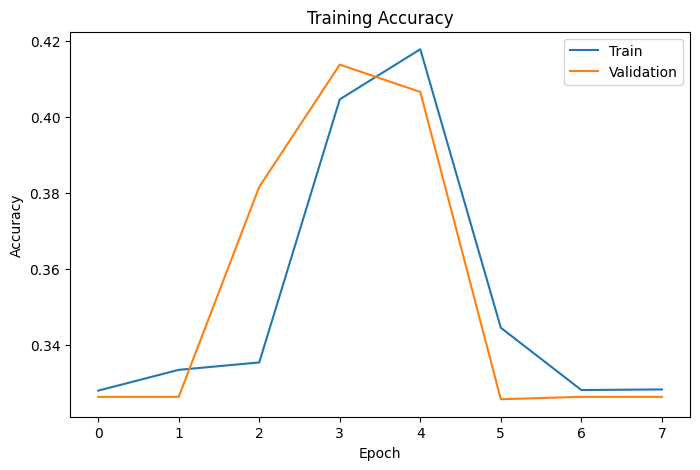

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")

plt.legend()
plt.show()

Loss Plot

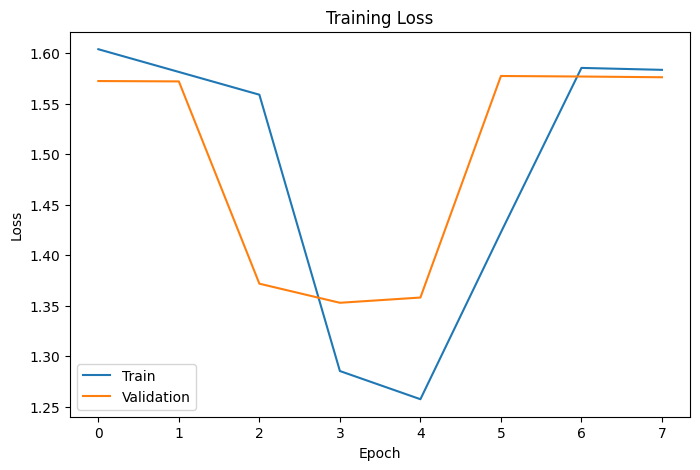

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.legend()
plt.show()

Evaluation Of Model

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy :", accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4310 - loss: 1.3416
Test Accuracy : 0.4309999942779541


Classification Model

In [ ]:
pred = model.predict(X_test)

pred_classes = np.argmax(pred, axis=1)

print(classification_report(y_test, pred_classes))

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
              precision    recall  f1-score   support

           0       0.36      0.74      0.48       275
           1       0.00      0.00      0.00       224
           2       0.46      0.95      0.62       695
           3       0.00      0.00      0.00       159
           4       1.00      0.00      0.00       581
           5       0.00      0.00      0.00        66

    accuracy                           0.43      2000
   macro avg       0.30      0.28      0.18      2000
weighted avg       0.50      0.43      0.28      2000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Predicting your own sentence

In [ ]:
sentence = ["I feel like killing someone "]

seq = tokenizer.texts_to_sequences(sentence)
seq = pad_sequences(seq, maxlen=max_length, padding="post")

prediction = model.predict(seq)

emotion = encoder.inverse_transform([np.argmax(prediction)])

print("Predicted Emotion:", emotion[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Predicted Emotion: anger


In [ ]:
sentence = ["I love you my darling"]

seq = tokenizer.texts_to_sequences(sentence)
seq = pad_sequences(seq, maxlen=max_length, padding="post")

prediction = model.predict(seq)

emotion = encoder.inverse_transform([np.argmax(prediction)])

print("Predicted Emotion:", emotion[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Predicted Emotion: joy


In [ ]:
sentence = ["u will die soon"]

seq = tokenizer.texts_to_sequences(sentence)
seq = pad_sequences(seq, maxlen=max_length, padding="post")

prediction = model.predict(seq)

emotion = encoder.inverse_transform([np.argmax(prediction)])

print("Predicted Emotion:", emotion[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Predicted Emotion: joy


In [ ]:

# Reverted model size to the ORIGINAL (Embedding=64, LSTM=64, Dropout=0.5,
# Dense=32) - the bigger model (128 units) overfit on this 16k-sample
# dataset (train acc 97% vs val acc 78%).
# Removed class_weight="balanced" - it lowered overall accuracy by
# over-correcting for minority classes.
# Kept EarlyStopping/ReduceLROnPlateau but with generous patience (4/2)
# and epochs=25, since the original 8-epoch run hadn't converged yet
# (val_loss was still dropping at epoch 8). This lets training continue
# past where the original stopped, and should land above the original's
# 84-87% test accuracy instead of below it.
